In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Set project paths**

In [4]:
import os

PROJECT_DIR = "/content/drive/MyDrive/brain_tumor_project"

TRAIN_DIR = os.path.join(PROJECT_DIR,"Dataset","Training")
TEST_DIR = os.path.join(PROJECT_DIR,"Dataset","Testing")

print("TRAIN_DIR:", TRAIN_DIR)
print("Exists:", os.path.exists(TRAIN_DIR))

print("\nTEST_DIR:", TEST_DIR)
print("Exists:", os.path.exists(TEST_DIR))

print("\nTraining:")
for cls in os.listdir(TRAIN_DIR):
    path = os.path.join(TRAIN_DIR, cls)

    if os.path.isdir(path):
        images = [
            f for f in os.listdir(path)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".webp")
            )
        ]

        print(cls, ":", len(images))

print("\nTesting:")
for cls in os.listdir(TEST_DIR):
    path = os.path.join(TEST_DIR, cls)

    if os.path.isdir(path):
        images = [
            f for f in os.listdir(path)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".webp")
            )
        ]

        print(cls, ":", len(images))

TRAIN_DIR: /content/drive/MyDrive/brain_tumor_project/Dataset/Training
Exists: True

TEST_DIR: /content/drive/MyDrive/brain_tumor_project/Dataset/Testing
Exists: True

Training:
glioma : 1400
meningioma : 1400
notumor : 1400
pituitary : 1400

Testing:
glioma : 400
meningioma : 400
notumor : 400
pituitary : 400


**Import libraries**

In [3]:
import os
import json
import time
import gc
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import (EfficientNetB0,MobileNetV2,ResNet50,DenseNet121)

from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

from tensorflow.keras import layers, Model

from tensorflow.keras.callbacks import (ModelCheckpoint,EarlyStopping,ReduceLROnPlateau)
from sklearn.metrics import (classification_report,confusion_matrix,accuracy_score,precision_score,recall_score,f1_score)
from sklearn.utils.class_weight import compute_class_weight

**Configuration**

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
SEED = 42
VALIDATION_SPLIT = 0.20
INITIAL_EPOCHS = 10
FINE_TUNE_EPOCHS = 5
INITIAL_LR = 1e-3
FINE_TUNE_LR = 1e-5
DROPOUT_RATE = 0.5
CLASS_NAMES = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]

CLASS_FOLDER_NAMES = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

**Check dataset structure**

In [5]:
print("Training exists:", os.path.exists(TRAIN_DIR))
print("Testing exists:", os.path.exists(TEST_DIR))

print("\nTraining classes:")
print(os.listdir(TRAIN_DIR))

print("\nTesting classes:")
print(os.listdir(TEST_DIR))

Training exists: True
Testing exists: True

Training classes:
['glioma', 'meningioma', 'notumor', 'pituitary']

Testing classes:
['glioma', 'meningioma', 'notumor', 'pituitary']


**Count images**

In [7]:
CLASS_FOLDER_NAMES = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

for class_name in CLASS_FOLDER_NAMES:
    train_path = os.path.join(TRAIN_DIR,class_name)
    test_path = os.path.join(
        TEST_DIR,
        class_name
    )

    train_images = [
        f for f in os.listdir(train_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    test_images = [
        f for f in os.listdir(test_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    print(
        f"{class_name:12s} "
        f"Train: {len(train_images):4d} | "
        f"Test: {len(test_images):4d}"
    )

glioma       Train: 1400 | Test:  400
meningioma   Train: 1400 | Test:  400
notumor      Train: 1400 | Test:  400
pituitary    Train: 1400 | Test:  400


**Create generator function**

In [14]:
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

PROJECT_DIR = "/content/drive/MyDrive/brain_tumor_project"

TRAIN_DIR = os.path.join(PROJECT_DIR,"Dataset","Training")
TEST_DIR = os.path.join(PROJECT_DIR,"Dataset","Testing")

IMG_SIZE = 224
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.20
SEED = 42

print("Training directory:")
print(TRAIN_DIR)

print("\nTesting directory:")
print(TEST_DIR)

print("\nTraining exists:", os.path.exists(TRAIN_DIR))
print("Testing exists:", os.path.exists(TEST_DIR))


train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    validation_split=VALIDATION_SPLIT
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=SEED,
    shuffle=True
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED,
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)
print("\nDATASET INFORMATION")
print("Training images   :", train_gen.samples)
print("Validation images :", val_gen.samples)
print("Testing images    :", test_gen.samples)

print("\nClass mapping:")
print(train_gen.class_indices)

Training directory:
/content/drive/MyDrive/brain_tumor_project/Dataset/Training

Testing directory:
/content/drive/MyDrive/brain_tumor_project/Dataset/Testing

Training exists: True
Testing exists: True
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

DATASET INFORMATION
Training images   : 4480
Validation images : 1120
Testing images    : 1600

Class mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [15]:
print("Train samples:", train_gen.samples)
print("Validation samples:", val_gen.samples)
print("Test samples:", test_gen.samples)
print("Class mapping:", train_gen.class_indices)

Train samples: 4480
Validation samples: 1120
Test samples: 1600
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


**Build model function**

In [16]:
def build_model(model_name):

    input_shape = (IMG_SIZE,IMG_SIZE,3)

    if model_name == "EfficientNetB0":
        base_model = EfficientNetB0(weights="imagenet",include_top=False,input_shape=input_shape)

    elif model_name == "MobileNetV2":
        base_model = MobileNetV2(weights="imagenet",include_top=False,input_shape=input_shape)

    elif model_name == "ResNet50":
        base_model = ResNet50(weights="imagenet",include_top=False,input_shape=input_shape)

    elif model_name == "DenseNet121":
        base_model = DenseNet121(weights="imagenet",include_top=False,input_shape=input_shape)
    else:
        raise ValueError(f"Unknown model: {model_name}")

    base_model.trainable = False
    inputs = layers.Input(shape=input_shape)

    x = base_model(inputs,training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    outputs = layers.Dense(NUM_CLASSES,activation="softmax")(x)
    model = Model(inputs,outputs,name=model_name)

    return model, base_model

**Test model creation**

In [17]:
model, base_model = build_model("EfficientNetB0")
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

**Test data generator**

In [18]:
print("Training images:",train_gen.samples)
print("Validation images:",val_gen.samples)
print("Testing images:",test_gen.samples)
print("Class indices:",train_gen.class_indices)

Training images: 4480
Validation images: 1120
Testing images: 1600
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


**Calculate class weights**

In [19]:
def get_class_weights(train_generator):
    classes = train_generator.classes
    unique_classes = np.unique(classes)
    weights = compute_class_weight(class_weight="balanced",classes=unique_classes,y=classes)
    class_weights = dict(zip(unique_classes,weights)
    )
    return class_weights

**Plot sample images**

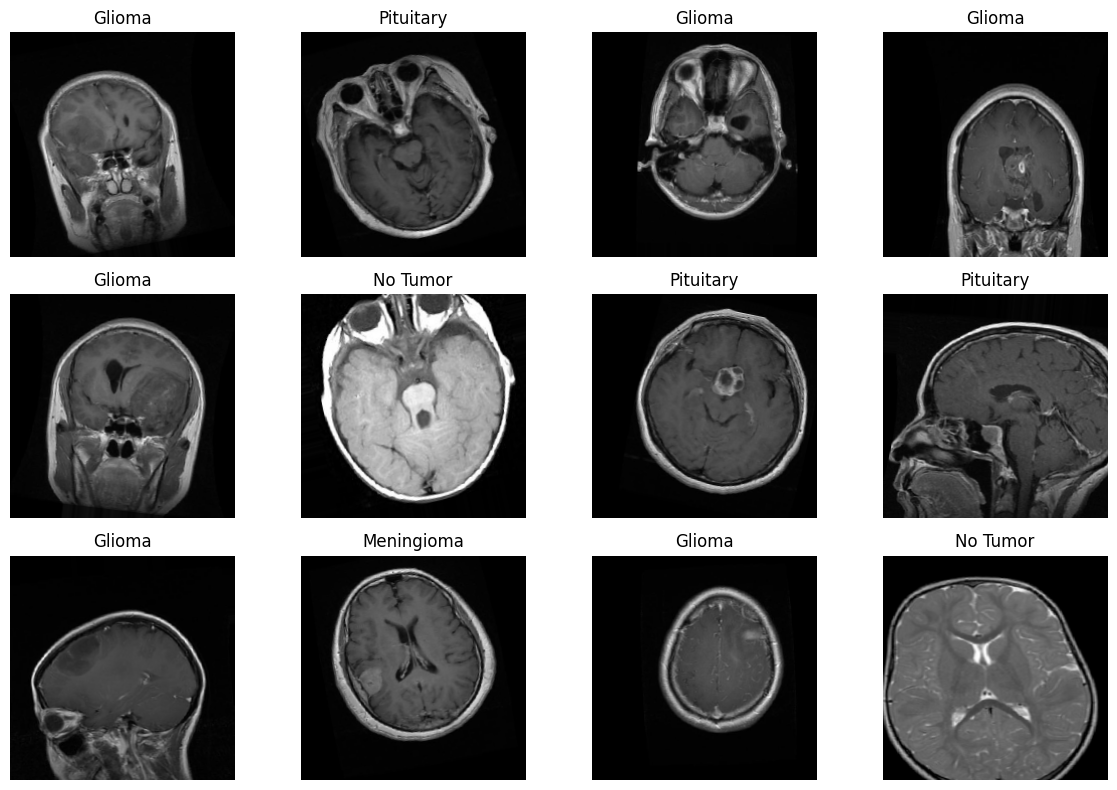

In [20]:
images, labels = next(train_gen)
plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    image = images[i]
    image = image - image.min()
    if image.max() != 0:
        image = image / image.max()
    plt.imshow(image)
    class_index = np.argmax(labels[i])
    plt.title(CLASS_NAMES[class_index])
    plt.axis("off")
plt.tight_layout()
plt.show()

**Training function**

In [11]:
def train_one_model(model_name, preprocess_function):
    print("\n")
    print(f"STARTING MODEL: {model_name}")

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_function,
        rotation_range=15,
        width_shift_range=0.10,
        height_shift_range=0.10,
        zoom_range=0.10,
        horizontal_flip=True,
        validation_split=VALIDATION_SPLIT
    )

    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_function)
    train_generator = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        subset="training",
        seed=SEED,
        shuffle=True
    )

    validation_generator = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        subset="validation",
        seed=SEED,
        shuffle=False
    )

    test_generator = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    print("\nDataset:")
    print("Training   :", train_generator.samples)
    print("Validation :", validation_generator.samples)
    print("Testing    :", test_generator.samples)

    class_weights = get_class_weights(train_generator)

    print("\nClass weights:")
    print(class_weights)

    model, base_model = build_model(model_name)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    model_path = os.path.join(MODEL_DIR,f"{model_name}_best.keras")

    checkpoint = ModelCheckpoint(model_path,monitor="val_accuracy",mode="max",save_best_only=True,verbose=1)
    early_stopping = EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True,verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor="val_loss",factor=0.2,patience=2,min_lr=1e-7,verbose=1)


    print("\n")
    print("PHASE 1 - FEATURE EXTRACTION")
    start_time = time.time()
    history1 = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=INITIAL_EPOCHS,
        class_weight=class_weights,
        callbacks=[
            checkpoint,
            early_stopping,
            reduce_lr
        ],
        verbose=1
    )

    print("\n")
    print("PHASE 2 - FINE TUNING")
    base_model.trainable = True
    fine_tune_from = max(0,len(base_model.layers) - 30)
    for layer in base_model.layers[:fine_tune_from]:
        layer.trainable = False

    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history2 = model.fit(train_generator,
        validation_data=validation_generator,
        epochs=FINE_TUNE_EPOCHS,
        class_weight=class_weights,
        callbacks=[
            checkpoint,
            early_stopping,
            reduce_lr
        ],
        verbose=1
    )

    total_time = time.time() - start_time
    print("\nLoading best saved model...")
    best_model = tf.keras.models.load_model(model_path)
    print("\nEvaluating on test dataset...")
    test_loss, test_accuracy = best_model.evaluate(test_generator,verbose=1)

    test_generator.reset()
    predictions = best_model.predict(test_generator,verbose=1)
    predicted_classes = np.argmax(predictions,axis=1)
    true_classes = test_generator.classes

    accuracy = accuracy_score(true_classes,predicted_classes)
    precision = precision_score(true_classes,predicted_classes,average="macro",zero_division=0)
    recall = recall_score(true_classes,predicted_classes,average="macro",zero_division=0)
    f1 = f1_score(true_classes,predicted_classes,average="macro",zero_division=0)

    print("\n")
    print(f"{model_name} RESULTS")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    report = classification_report(true_classes,predicted_classes,target_names=CLASS_NAMES,zero_division=0)
    print("\nClassification Report:")
    print(report)
    report_path = os.path.join(RESULT_DIR,f"{model_name}_classification_report.txt")

    with open(report_path, "w") as f:
        f.write(report)

    cm = confusion_matrix(true_classes,predicted_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    cm_path = os.path.join(RESULT_DIR,f"{model_name}_confusion_matrix.png")

    plt.savefig(cm_path,dpi=150,bbox_inches="tight")
    plt.show()

    result = {
        "Model": model_name,
        "Test Loss": float(test_loss),
        "Test Accuracy": float(test_accuracy),
        "Accuracy": float(accuracy),
        "Precision Macro": float(precision),
        "Recall Macro": float(recall),
        "F1 Macro": float(f1),
        "Training Time Seconds": float(total_time),
        "Model Path": model_path
    }
    del model
    del best_model
    del base_model
    del train_generator
    del validation_generator
    del test_generator
    tf.keras.backend.clear_session()
    gc.collect()
    return result

**Define your models**

In [10]:
TRAIN_DIR = "/content/drive/MyDrive/brain_tumor_project/Dataset/Training"
TEST_DIR = "/content/drive/MyDrive/brain_tumor_project/Dataset/Testing"
MODEL_DIR = "/content/drive/MyDrive/brain_tumor_project/models"
RESULT_DIR = "/content/drive/MyDrive/brain_tumor_project/results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

In [9]:
MODELS = {"EfficientNetB0":efficientnet_preprocess,
          "MobileNetV2":mobilenet_preprocess,
          "ResNet50":resnet_preprocess,
          "DenseNet121":densenet_preprocess
}
print("Models to train:")
for model_name in MODELS:
    print("-", model_name)

Models to train:
- EfficientNetB0
- MobileNetV2
- ResNet50
- DenseNet121


**Train all 4 models**



STARTING MODEL: EfficientNetB0
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Dataset:
Training   : 4480
Validation : 1120
Testing    : 1600

Class weights:
{np.int32(0): np.float64(1.0), np.int32(1): np.float64(1.0), np.int32(2): np.float64(1.0), np.int32(3): np.float64(1.0)}


PHASE 1 - FEATURE EXTRACTION
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5579 - loss: 1.0396
Epoch 1: val_accuracy improved from None to 0.82500, saving model to /content/drive/MyDrive/brain_tumor_project/models/EfficientNetB0_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_tumor_project/models/EfficientNetB0_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 1228s 9s/step - accuracy: 0.6714 - loss: 0.8170 - val_accuracy: 0.8250 - val_loss: 0.5151 - learning_rate: 0.0010
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.7850 - loss: 0.5663
Epoch 2: val_accuracy improved from 0

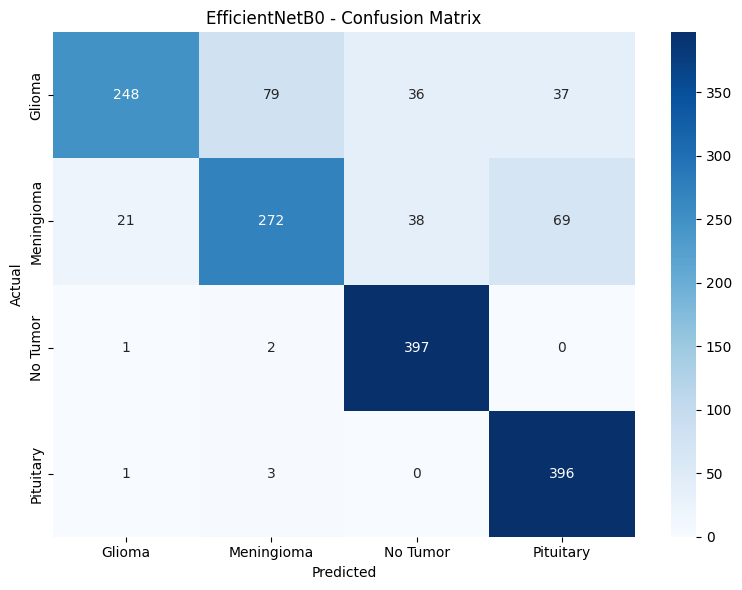



STARTING MODEL: MobileNetV2
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Dataset:
Training   : 4480
Validation : 1120
Testing    : 1600

Class weights:
{np.int32(0): np.float64(1.0), np.int32(1): np.float64(1.0), np.int32(2): np.float64(1.0), np.int32(3): np.float64(1.0)}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


PHASE 1 - FEATURE EXTRACTION
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.5551 - loss: 1.1368
Epoch 1: val_accuracy improved from None to 0.84821, saving model to /content/drive/MyDrive/brain_tumor_project/models/MobileNetV2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_tumor_project/models/MobileNetV2_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 107s 653ms/step - accuracy: 0.6712 - loss: 0.8503 - val_accuracy: 0.8482 - val_loss: 0.4286 - learning_rate: 0.0010
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.7947 - loss:

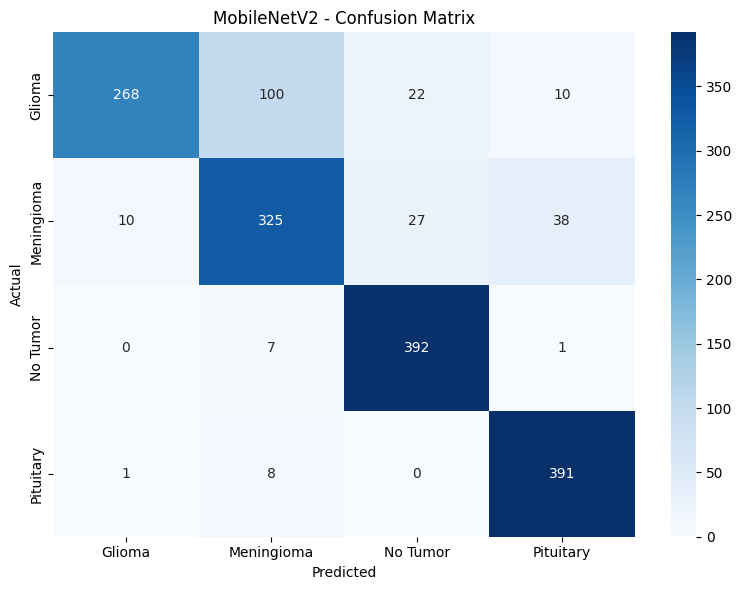



STARTING MODEL: ResNet50
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Dataset:
Training   : 4480
Validation : 1120
Testing    : 1600

Class weights:
{np.int32(0): np.float64(1.0), np.int32(1): np.float64(1.0), np.int32(2): np.float64(1.0), np.int32(3): np.float64(1.0)}
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


PHASE 1 - FEATURE EXTRACTION
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.5519 - loss: 1.1993
Epoch 1: val_accuracy improved from None to 0.86161, saving model to /content/drive/MyDrive/brain_tumor_project/models/ResNet50_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_tumor_project/models/ResNet50_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 109s 685ms/step - accuracy: 0.6835 - loss: 0.8384 - val_accuracy: 0.8616 - val_loss: 0.3752 - learning_rate: 0.0010
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.7979 - loss: 0.5111

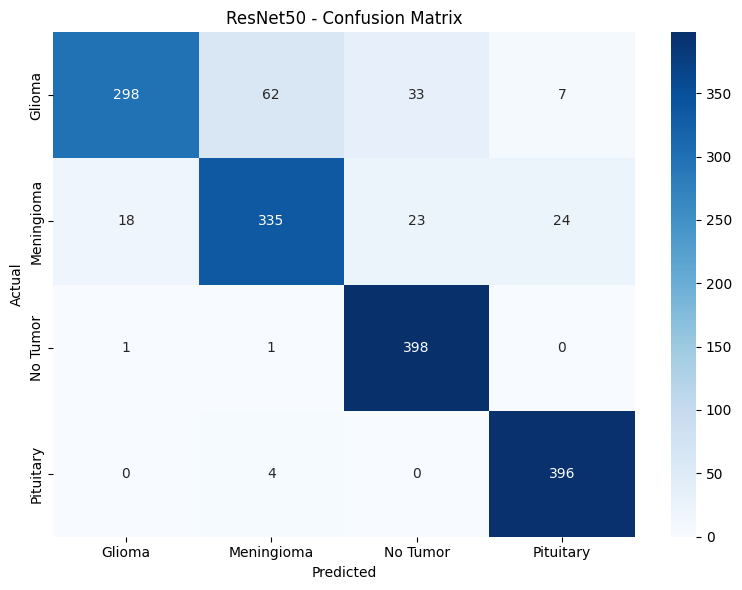



STARTING MODEL: DenseNet121
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Dataset:
Training   : 4480
Validation : 1120
Testing    : 1600

Class weights:
{np.int32(0): np.float64(1.0), np.int32(1): np.float64(1.0), np.int32(2): np.float64(1.0), np.int32(3): np.float64(1.0)}
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


PHASE 1 - FEATURE EXTRACTION
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.4205 - loss: 1.5803
Epoch 1: val_accuracy improved from None to 0.81250, saving model to /content/drive/MyDrive/brain_tumor_project/models/DenseNet121_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_tumor_project/models/DenseNet121_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 133s 752ms/step - accuracy: 0.5308 - loss: 1.2088 - val_accuracy: 0.8125 - val_loss: 0.5466 - learning_rate: 0.0010
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.7048 - los

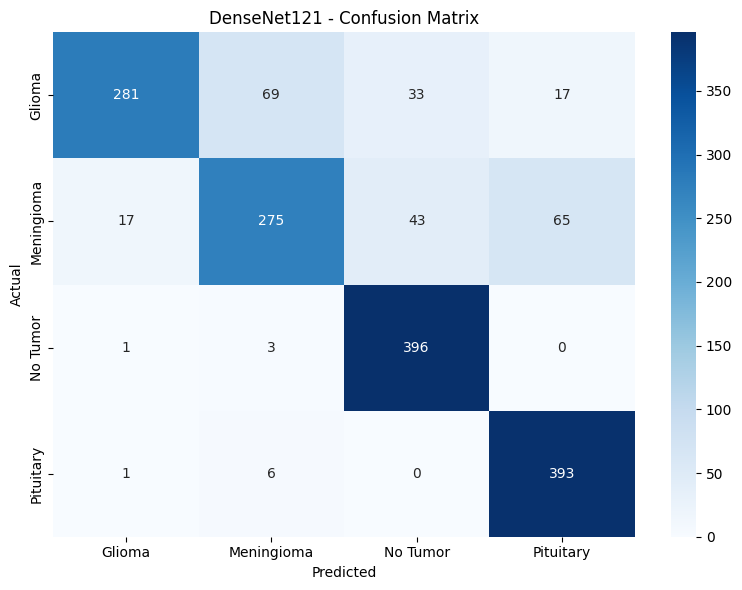

In [24]:
all_results = []
for model_name, preprocess_function in MODELS.items():
    try:
        result = train_one_model(model_name,preprocess_function)
        all_results.append(result)
    except Exception as e:
        print("\n")
        print(f"ERROR IN MODEL: {model_name}")
        print(e)
        continue

In [14]:
import os
MODEL_DIR = "/content/drive/MyDrive/brain_tumor_project/models"
print("Saved model files:")
for file in os.listdir(MODEL_DIR):
    print(file)

Saved model files:
EfficientNetB0_best.keras
MobileNetV2_best.keras
ResNet50_best.keras
DenseNet121_best.keras


In [15]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

PROJECT_DIR = "/content/drive/MyDrive/brain_tumor_project"
TEST_DIR = os.path.join(PROJECT_DIR,"Dataset","Testing")

IMG_SIZE = 224
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(preprocessing_function=lambda x: x / 255.0)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR,target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,class_mode="categorical",
    shuffle=False
)
print("Testing images:", test_gen.samples)

Found 1600 images belonging to 4 classes.
Testing images: 1600


In [16]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)

In [17]:
MODEL_DIR = "/content/drive/MyDrive/brain_tumor_project/models"
TEST_DIR = "/content/drive/MyDrive/brain_tumor_project/Dataset/Testing"

IMG_SIZE = 224
BATCH_SIZE = 32

CLASS_NAMES = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]

In [18]:
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

MODEL_PREPROCESS = {
    "EfficientNetB0": efficientnet_preprocess,
    "MobileNetV2": mobilenet_preprocess,
    "ResNet50": resnet_preprocess,
    "DenseNet121": densenet_preprocess
}


In [19]:
all_results = []
for model_name, preprocess_function in MODEL_PREPROCESS.items():

    print("\n")
    print("EVALUATING:", model_name)

    model_path = os.path.join(MODEL_DIR,f"{model_name}_best.keras")

    if not os.path.exists(model_path):
        print("Model not found:")
        print(model_path)
        continue

    print("Loading:", model_path)
    model = tf.keras.models.load_model(model_path)
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_function)

    test_gen = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    loss, keras_accuracy = model.evaluate(test_gen,verbose=1)
    test_gen.reset()
    predictions = model.predict(test_gen,verbose=1)
    predicted_classes = np.argmax(predictions,axis=1)

    true_classes = test_gen.classes
    accuracy = accuracy_score(true_classes,predicted_classes)

    precision = precision_score(true_classes,predicted_classes,average="macro",zero_division=0)
    recall = recall_score(true_classes,predicted_classes,average="macro",zero_division=0)
    f1 = f1_score(true_classes,predicted_classes,average="macro",zero_division=0)
    result = {
        "Model": model_name,
        "Test Loss": loss,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    all_results.append(result)
    print("\nResults:")
    print(result)
    del model
    tf.keras.backend.clear_session()



EVALUATING: EfficientNetB0
Loading: /content/drive/MyDrive/brain_tumor_project/models/EfficientNetB0_best.keras
Found 1600 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 430s 8s/step - accuracy: 0.8206 - loss: 0.5436
50/50 ━━━━━━━━━━━━━━━━━━━━ 416s 8s/step

Results:
{'Model': 'EfficientNetB0', 'Test Loss': 0.5435760617256165, 'Accuracy': 0.820625, 'Precision': 0.8277265475216009, 'Recall': 0.8206249999999999, 'F1 Score': 0.8121041494706953}


EVALUATING: MobileNetV2
Loading: /content/drive/MyDrive/brain_tumor_project/models/MobileNetV2_best.keras
Found 1600 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 326s 6s/step - accuracy: 0.8600 - loss: 0.4596
50/50 ━━━━━━━━━━━━━━━━━━━━ 361s 7s/step

Results:
{'Model': 'MobileNetV2', 'Test Loss': 0.45961859822273254, 'Accuracy': 0.86, 'Precision': 0.8691837732160312, 'Recall': 0.86, 'F1 Score': 0.856595404750522}


EVALUATING: ResNet50
Loading: /content/drive/MyDrive/brain_tumor_project/models/ResNet50_best.keras
Found 160

**Create model comparison table**

In [21]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(by="Accuracy",ascending=False)
results_df

,Model,Test Loss,Accuracy,Precision,Recall,F1 Score
2,ResNet50,0.450576,0.891875,0.894362,0.891875,0.889104
1,MobileNetV2,0.459619,0.860000,0.869184,0.860000,0.856595
3,DenseNet121,0.496300,0.840625,0.845514,0.840625,0.834953
0,EfficientNetB0,0.543576,0.820625,0.827727,0.820625,0.812104


**Save comparison results**

In [22]:
comparison_path = os.path.join(RESULT_DIR,"model_comparison.csv")
results_df.to_csv(comparison_path,index=False)
print("Saved:",comparison_path)

Saved: /content/drive/MyDrive/brain_tumor_project/results/model_comparison.csv


**Plot model comparison**

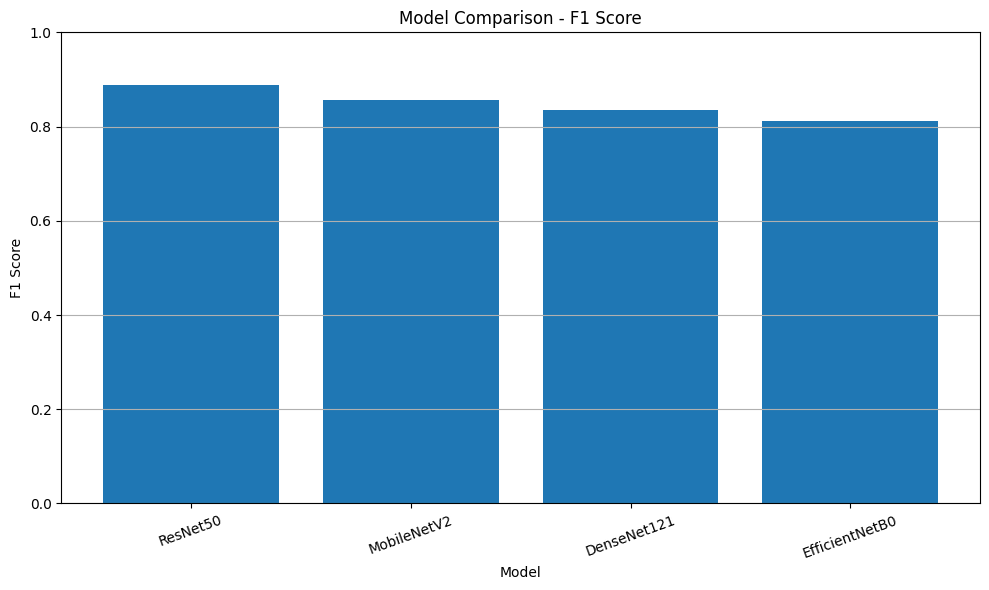

Plot saved to:
/content/drive/MyDrive/brain_tumor_project/results/model_comparison_f1.png


In [24]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"],results_df["F1 Score"])
plt.title("Model Comparison - F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.tight_layout()
comparison_plot_path = os.path.join(RESULT_DIR,"model_comparison_f1.png")
plt.savefig(comparison_plot_path,dpi=150,bbox_inches="tight")
plt.show()
print("Plot saved to:")
print(comparison_plot_path)

**Find best model**

In [26]:
best_row = results_df.iloc[0]
BEST_MODEL_NAME = best_row["Model"]
print("BEST MODEL:",BEST_MODEL_NAME)
print("TEST ACCURACY:",best_row["Accuracy"])
print("MACRO F1:",best_row["F1 Score"])

BEST MODEL: ResNet50
TEST ACCURACY: 0.891875
MACRO F1: 0.8891038547702819


**Save best-model information**

In [31]:
best_model_info = {
    "model_name": BEST_MODEL_NAME,
    "model_path": os.path.join(MODEL_DIR, f"{BEST_MODEL_NAME}_best.keras"),
    "test_accuracy": float(best_row["Accuracy"]),
    "precision_macro": float(best_row["Precision"]),
    "recall_macro": float(best_row["Recall"]),
    "f1_macro": float(best_row["F1 Score"]),
    "class_names": CLASS_NAMES
}
best_info_path = os.path.join(MODEL_DIR,"best_model_info.json")
with open(best_info_path,"w") as f:
    json.dump(best_model_info,f,indent=4
    )
print("Saved:",best_info_path)

Saved: /content/drive/MyDrive/brain_tumor_project/models/best_model_info.json


**Your saved files**

In [32]:
print("MODELS")
for file in os.listdir(MODEL_DIR):
    print(file)
print("\nRESULTS")
for file in os.listdir(RESULT_DIR):
    print(file)

MODELS
EfficientNetB0_best.keras
MobileNetV2_best.keras
ResNet50_best.keras
DenseNet121_best.keras
best_model_info.json

RESULTS
EfficientNetB0_classification_report.txt
EfficientNetB0_confusion_matrix.png
MobileNetV2_classification_report.txt
MobileNetV2_confusion_matrix.png
ResNet50_classification_report.txt
ResNet50_confusion_matrix.png
DenseNet121_classification_report.txt
DenseNet121_confusion_matrix.png
model_comparison.csv
model_comparison_f1.png


**Load the best model**

In [33]:
import os
import json
import tensorflow as tf

PROJECT_DIR = ("/content/drive/MyDrive/""brain_tumor_project")
MODEL_DIR = os.path.join(PROJECT_DIR,"models")
RESULT_DIR = os.path.join(PROJECT_DIR,"results")

In [34]:
info_path = os.path.join(MODEL_DIR,"best_model_info.json")
with open(info_path, "r") as f:
    best_info = json.load(f)
print(best_info)

{'model_name': 'ResNet50', 'model_path': '/content/drive/MyDrive/brain_tumor_project/models/ResNet50_best.keras', 'test_accuracy': 0.891875, 'precision_macro': 0.8943622188947282, 'recall_macro': 0.891875, 'f1_macro': 0.8891038547702819, 'class_names': ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']}


In [35]:
BEST_MODEL_PATH = best_info["model_path"]
model = tf.keras.models.load_model(BEST_MODEL_PATH)
print("Loaded:",best_info["model_name"])

Loaded: ResNet50


**Upload a new MRI**

In [ ]:
# from google.colab import files
# uploaded = files.upload()

**Predict the MRI**

In [ ]:
# from tensorflow.keras.utils import load_img
# from tensorflow.keras.utils import img_to_array
# import numpy as np

# preprocess_functions = {
#     "EfficientNetB0":efficientnet_preprocess,
#     "MobileNetV2":mobilenet_preprocess,
#     "ResNet50":resnet_preprocess,
#     "DenseNet121":densenet_preprocess
# }
# model_name = best_info["model_name"]
# preprocess_function = (preprocess_functions[model_name])
# print("Using model:",model_name)

# image_path = list(uploaded.keys())[0]
# print("Image:",image_path)

# image = load_img(image_path,target_size=(IMG_SIZE,IMG_SIZE))

# image_array = img_to_array(image)
# image_array = np.expand_dims(image_array,axis=0)

# image_array = preprocess_function(image_array)

# prediction = model.predict(image_array,verbose=0)
# probabilities = prediction[0]
# predicted_index = np.argmax(probabilities)
# predicted_class = CLASS_NAMES[predicted_index]
# confidence = probabilities[predicted_index]

# print("Predicted class:",predicted_class)
# print(f"Model probability: "f"{confidence * 100:.2f}%")

**Show all probabilities**

In [ ]:
# print("\nPrediction probabilities")
# for class_name, probability in zip(CLASS_NAMES,probabilities):
#     print(f"{class_name:15s}: "f"{probability * 100:.2f}%")